# Notebook 1: Data Cleaning & Wrangling
## Twitter US Airline Sentiment Dataset

**Dataset:** Twitter US Airline Sentiment — 14,640 tweets about 6 US airlines, labeled as positive / neutral / negative.

**Goal of this notebook:** Load the raw CSV, audit its quality, fix every data quality issue we find (missing values, duplicates, noisy text, wrong dtypes), and save a clean dataset ready for EDA and modelling.

**Output file:** `cleaned_data.csv`

---

## Setup & Imports

We import every library we need up front so the notebook can be re-run cleanly from top to bottom.

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Imports and global configuration
# WHY: Centralise all imports so any missing library surfaces immediately,
#      not mid-notebook. Setting seeds and display options ensures the notebook
#      produces identical output on every run.
# ─────────────────────────────────────────────────────────────────────────────

# ── Standard library ────────────────────────────────────────────────────────
import os          # file-path operations
import re          # regular expressions for text cleaning
import warnings    # suppress non-critical warnings during library imports
warnings.filterwarnings('ignore')

# ── Data manipulation ────────────────────────────────────────────────────────
import numpy as np          # numerical operations
import pandas as pd         # tabular data handling

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt   # base plotting library
import seaborn as sns             # higher-level statistical plots built on matplotlib

# ── NLP libraries ────────────────────────────────────────────────────────────
import nltk                        # Natural Language Toolkit – tokenisation, stopwords, etc.
from nltk.corpus import stopwords  # list of common English stop words

# Download required NLTK data packages (only needed once; safe to re-run)
nltk.download('punkt',      quiet=True)
nltk.download('stopwords',  quiet=True)
nltk.download('wordnet',    quiet=True)
nltk.download('punkt_tab',  quiet=True)

# ── Sklearn utilities ────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder  # convert string labels → integers

# ── Reproducibility ──────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Pandas display options ───────────────────────────────────────────────────
pd.set_option('display.max_colwidth', 120)   # show more text in cells
pd.set_option('display.max_columns',  50)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Plot style ───────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13

print('All libraries imported successfully.')
print(f'pandas  {pd.__version__}  |  numpy  {np.__version__}')

All libraries imported successfully.
pandas  2.2.3  |  numpy  2.1.3


---
## Section 1 — Data Loading

The dataset lives in the `archive/` subfolder of this project. We load it with `pd.read_csv` and immediately take a first look at its shape, column types, and sample rows.

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Load the raw CSV
# WHY: We need to verify the file loads without errors and get our first
#      look at the raw data before any transformation.
# ─────────────────────────────────────────────────────────────────────────────

DATA_PATH = os.path.join('archive', 'Tweets.csv')

df_raw = pd.read_csv(DATA_PATH)

print(f'Dataset shape: {df_raw.shape}  →  {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print()
df_raw.head(3)

Dataset shape: (14640, 15)  →  14,640 rows × 15 columns



,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials to the experience... tacky.,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I need to take another trip!,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Column-level data dictionary
# WHY: Understanding what each column represents is essential before we
#      decide how to clean or drop it.
# ─────────────────────────────────────────────────────────────────────────────

# Columns and their meaning
col_description = {
    'tweet_id'                      : 'Unique identifier for each tweet (not useful for modelling)',
    'airline_sentiment'             : '*** TARGET LABEL *** – positive / neutral / negative',
    'airline_sentiment_confidence'  : 'Confidence score (0–1) assigned by human annotators',
    'negativereason'                : 'Category of complaint for negative tweets (often missing)',
    'negativereason_confidence'     : 'Confidence score for negativereason',
    'airline'                       : 'Airline name (6 airlines: United, US Airways, American, Southwest, Delta, Virgin America)',
    'airline_sentiment_gold'        : 'Gold-standard label (rarely filled)',
    'name'                          : 'Twitter username of the author',
    'negativereason_gold'           : 'Gold-standard negative reason (rarely filled)',
    'retweet_count'                 : 'Number of times the tweet was retweeted',
    'text'                          : '*** MAIN FEATURE *** – raw tweet text',
    'tweet_coord'                   : 'Geographic coordinates (mostly missing)',
    'tweet_created'                 : 'Timestamp of the tweet',
    'tweet_location'                : 'User-supplied location string (noisy)',
    'user_timezone'                 : 'Timezone set in user profile',
}

desc_df = pd.DataFrame(col_description.items(), columns=['Column', 'Description'])
print(desc_df.to_string(index=False))

                      Column                                                                               Description
                    tweet_id                               Unique identifier for each tweet (not useful for modelling)
           airline_sentiment                                      *** TARGET LABEL *** – positive / neutral / negative
airline_sentiment_confidence                                       Confidence score (0–1) assigned by human annotators
              negativereason                                 Category of complaint for negative tweets (often missing)
   negativereason_confidence                                                       Confidence score for negativereason
                     airline Airline name (6 airlines: United, US Airways, American, Southwest, Delta, Virgin America)
      airline_sentiment_gold                                                       Gold-standard label (rarely filled)
                        name                    

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Data types of each column
# WHY: Knowing dtypes tells us which columns need type-casting (e.g., dates
#      stored as strings, numeric IDs stored as floats).
# ─────────────────────────────────────────────────────────────────────────────

print('Column dtypes:')
print(df_raw.dtypes)
print()
print(f'Memory usage: {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

Column dtypes:
tweet_id                          int64
airline_sentiment                object
airline_sentiment_confidence    float64
negativereason                   object
negativereason_confidence       float64
airline                          object
airline_sentiment_gold           object
name                             object
negativereason_gold              object
retweet_count                     int64
text                             object
tweet_coord                      object
tweet_created                    object
tweet_location                   object
user_timezone                    object
dtype: object

Memory usage: 9.87 MB


---
## Section 2 — Initial Data Audit

Before touching anything we do a full health-check: missing values, duplicates, class balance. This gives us a *baseline* to compare against after cleaning.

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Missing value audit
# WHY: Columns with >50% missing are likely unusable as features; columns with
#      <5% missing can often be imputed. We need this map before deciding.
# ─────────────────────────────────────────────────────────────────────────────

missing_count = df_raw.isnull().sum()
missing_pct   = (missing_count / len(df_raw) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count'  : missing_count,
    'Missing %'      : missing_pct
}).sort_values('Missing %', ascending=False)

print('=== Missing Value Report ===')
print(missing_df[missing_df['Missing Count'] > 0].to_string())

=== Missing Value Report ===
                           Missing Count  Missing %
negativereason_gold                14608    99.7800
airline_sentiment_gold             14600    99.7300
tweet_coord                        13621    93.0400
negativereason                      5462    37.3100
user_timezone                       4820    32.9200
tweet_location                      4733    32.3300
negativereason_confidence           4118    28.1300


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Duplicate row audit
# WHY: Duplicate rows inflate training data and can bias the model by over-
#      representing certain examples.
# ─────────────────────────────────────────────────────────────────────────────

n_dups = df_raw.duplicated().sum()
n_text_dups = df_raw['text'].duplicated().sum()

print(f'Exact duplicate rows  : {n_dups}')
print(f'Duplicate tweet texts : {n_text_dups}  (same text, possibly different metadata)')

Exact duplicate rows  : 36
Duplicate tweet texts : 213  (same text, possibly different metadata)


=== Target Class Distribution ===
                   Count  Percentage
airline_sentiment                   
negative            9178     62.6900
neutral             3099     21.1700
positive            2363     16.1400



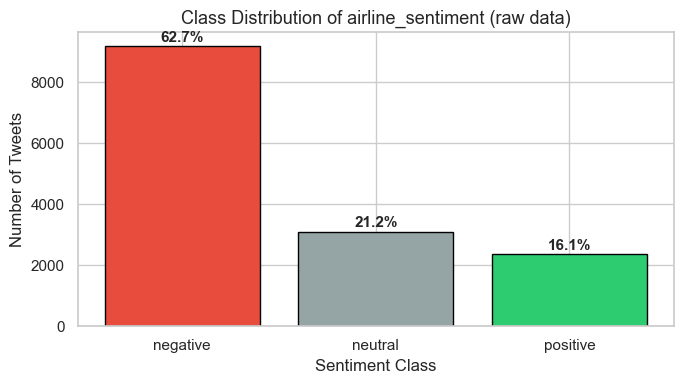

Observation: The dataset is IMBALANCED — ~63% of tweets are negative.
This is expected for an airline complaint dataset and must be accounted for in modelling.


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Class distribution of the target label
# WHY: Knowing if the dataset is imbalanced is critical — an imbalanced target
#      means accuracy alone is a misleading metric, and we may need to stratify
#      our train/test split.
# ─────────────────────────────────────────────────────────────────────────────

class_dist = df_raw['airline_sentiment'].value_counts()
class_pct  = df_raw['airline_sentiment'].value_counts(normalize=True).mul(100).round(2)

class_df = pd.DataFrame({'Count': class_dist, 'Percentage': class_pct})
print('=== Target Class Distribution ===')
print(class_df)
print()

# Visualise the class imbalance
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#e74c3c', '#95a5a6', '#2ecc71']   # red=negative, grey=neutral, green=positive
bars = ax.bar(class_dist.index, class_dist.values, color=colors, edgecolor='black')
for bar, pct in zip(bars, class_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Class Distribution of airline_sentiment (raw data)')
ax.set_xlabel('Sentiment Class')
ax.set_ylabel('Number of Tweets')
plt.tight_layout()
plt.show()

print('Observation: The dataset is IMBALANCED — ~63% of tweets are negative.')
print('This is expected for an airline complaint dataset and must be accounted for in modelling.')

---
## Section 3 — Handling Missing Values

Strategy per column:
- `text` (main feature) → **drop** any row where text is null (we cannot use a tweet without text)
- `tweet_coord`, `airline_sentiment_gold`, `negativereason_gold` → **drop** entire columns (>90% missing, not useful)
- `negativereason` → **fill** with `'unknown'` (it's a categorical that's naturally missing for non-negative tweets)
- `negativereason_confidence` → **fill** with 0 (no confidence = no reason)
- `tweet_location`, `user_timezone` → **fill** with `'unknown'`


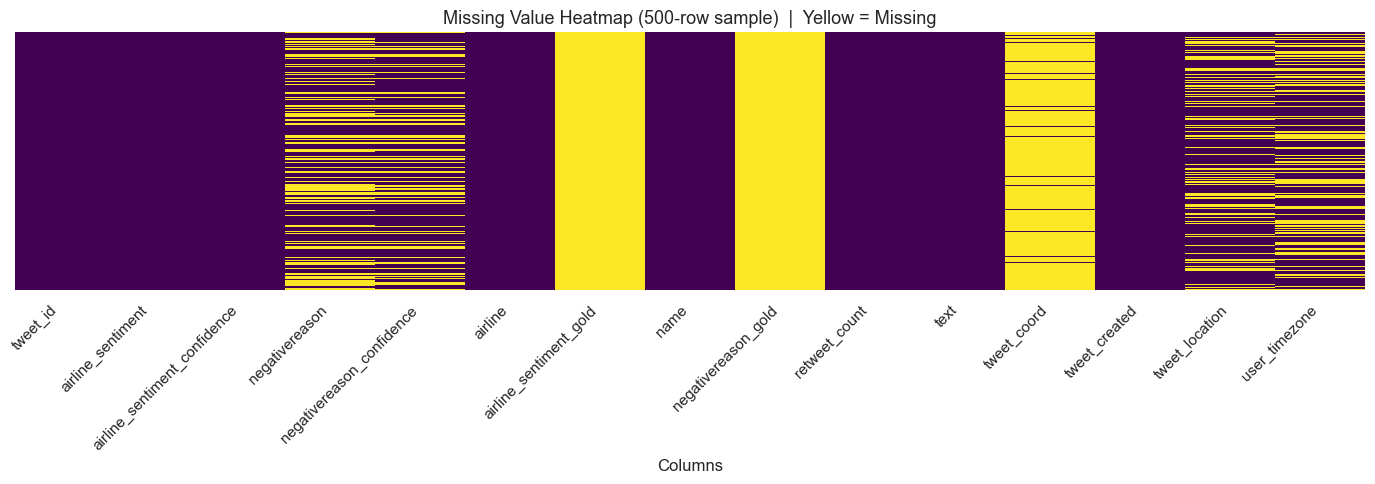

tweet_coord, airline_sentiment_gold, negativereason_gold are almost entirely yellow → drop them.
negativereason, tweet_location, user_timezone have partial missingness → fill them.


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Visualise missing data pattern as a heatmap
# WHY: A visual map is faster to read than a table when many columns have
#      missing values at different rates.
# ─────────────────────────────────────────────────────────────────────────────

# Sample 500 rows so the heatmap renders quickly
sample_df = df_raw.sample(500, random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    sample_df.isnull(),
    yticklabels=False,
    cbar=False,
    cmap='viridis',
    ax=ax
)
ax.set_title('Missing Value Heatmap (500-row sample)  |  Yellow = Missing')
ax.set_xlabel('Columns')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('tweet_coord, airline_sentiment_gold, negativereason_gold are almost entirely yellow → drop them.')
print('negativereason, tweet_location, user_timezone have partial missingness → fill them.')

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Apply missing-value strategy — work on a copy so raw data is untouched
# WHY: Always transform on a copy. This lets us compare before/after and
#      makes debugging much easier.
# ─────────────────────────────────────────────────────────────────────────────

df = df_raw.copy()
rows_before = len(df)
print(f'Rows BEFORE missing-value treatment: {rows_before:,}')

# 1. Drop columns that are almost entirely missing
cols_to_drop = ['tweet_coord', 'airline_sentiment_gold', 'negativereason_gold']
df.drop(columns=cols_to_drop, inplace=True)
print(f'  → Dropped columns: {cols_to_drop}')

# 2. Drop rows where the main text feature is null
null_text = df['text'].isnull().sum()
df.dropna(subset=['text'], inplace=True)
print(f'  → Dropped {null_text} rows with null text')

# 3. Fill categorical nulls with 'unknown'
df['negativereason'].fillna('unknown',  inplace=True)
df['tweet_location'].fillna('unknown',  inplace=True)
df['user_timezone'].fillna('unknown',   inplace=True)

# 4. Fill numeric null with 0
df['negativereason_confidence'].fillna(0.0, inplace=True)

rows_after = len(df)
print(f'Rows AFTER  missing-value treatment: {rows_after:,}')
print(f'  → Net rows removed: {rows_before - rows_after}')
print()
print('Remaining nulls:')
remaining = df.isnull().sum()
print(remaining[remaining > 0] if remaining.sum() > 0 else '  None — all nulls resolved.')

Rows BEFORE missing-value treatment: 14,640
  → Dropped columns: ['tweet_coord', 'airline_sentiment_gold', 'negativereason_gold']
  → Dropped 0 rows with null text
Rows AFTER  missing-value treatment: 14,640
  → Net rows removed: 0

Remaining nulls:
  None — all nulls resolved.


---
## Section 4 — Handling Duplicates

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Remove exact duplicate rows and duplicate tweet texts
# WHY: Exact-text duplicates in a text classification dataset cause data leakage
#      — the same sentence appearing in both train and test inflates test accuracy.
# ─────────────────────────────────────────────────────────────────────────────

rows_before_dup = len(df)

# Step 1: Remove rows where every column is identical
df.drop_duplicates(inplace=True)
after_full_dup = len(df)
print(f'Exact duplicate rows removed: {rows_before_dup - after_full_dup}')

# Step 2: Remove rows where the tweet TEXT is identical (keep first occurrence)
# Rationale: even if metadata differs, the same text string will produce the
#             same feature vector in any text model — keeping it twice is noise.
df.drop_duplicates(subset=['text'], keep='first', inplace=True)
after_text_dup = len(df)
print(f'Duplicate-text rows removed  : {after_full_dup - after_text_dup}')
print(f'Final row count              : {after_text_dup:,}')

# Reset the index so it's clean 0..N-1
df.reset_index(drop=True, inplace=True)
print()
df.head(3)

Exact duplicate rows removed: 39
Duplicate-text rows removed  : 174
Final row count              : 14,427



,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,name,retweet_count,text,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,unknown,0.0000,Virgin America,cairdin,0,@VirginAmerica What @dhepburn said.,2015-02-24 11:35:52 -0800,unknown,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,unknown,0.0000,Virgin America,jnardino,0,@VirginAmerica plus you've added commercials to the experience... tacky.,2015-02-24 11:15:59 -0800,unknown,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,unknown,0.0000,Virgin America,yvonnalynn,0,@VirginAmerica I didn't today... Must mean I need to take another trip!,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)


---
## Section 5 — Text-Specific Cleaning

We build one reusable `clean_text()` function. Every transformation lives inside it so we can call the same function consistently in all three notebooks.

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Define the clean_text() function
# WHY: A single, well-tested cleaning function means the exact same pipeline
#      is applied during training AND inference — preventing train/serve skew.
# ─────────────────────────────────────────────────────────────────────────────

def clean_text(text: str, remove_numbers: bool = False) -> str:
    """
    Clean raw tweet text for NLP modelling.

    Steps applied in order:
      1. Lowercase
      2. Remove Twitter @mentions (e.g. @VirginAmerica) — they are noise
      3. Remove URLs (http/https/www)
      4. Remove HTML tags (e.g. &amp;)
      5. Remove email addresses
      6. Remove special characters and punctuation (keep letters, digits, spaces)
      7. Optionally remove digits
      8. Collapse multiple whitespace into single space and strip

    Parameters
    ----------
    text           : raw string
    remove_numbers : if True, digits are also stripped

    Returns
    -------
    Cleaned lowercase string
    """
    if not isinstance(text, str):
        return ''

    # 1. Lowercase
    text = text.lower()

    # 2. Remove @mentions
    text = re.sub(r'@\w+', ' ', text)

    # 3. Remove URLs
    text = re.sub(r'http\S+|www\.\S+', ' ', text)

    # 4. Remove HTML tags and entities (e.g. <br/>, &amp;)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'&[a-z]+;', ' ', text)

    # 5. Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)

    # 6. Remove special characters — keep only letters, digits, and spaces
    text = re.sub(r'[^a-z0-9\s]', ' ', text)

    # 7. Optionally remove digits
    if remove_numbers:
        text = re.sub(r'\d+', ' ', text)

    # 8. Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

print('clean_text() defined.')

clean_text() defined.


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Show before vs after for 5 sample rows
# WHY: Always visually verify text cleaning — regex bugs are silent and can
#      wipe out legitimate content.
# ─────────────────────────────────────────────────────────────────────────────

sample_rows = df.sample(5, random_state=RANDOM_STATE)[['text']].copy()
sample_rows['cleaned'] = sample_rows['text'].apply(clean_text)

print('=== Before vs After Text Cleaning ===')
for i, row in sample_rows.iterrows():
    print(f'\n[Row {i}]')
    print(f'  BEFORE: {row["text"]}')
    print(f'  AFTER : {row["cleaned"]}')

=== Before vs After Text Cleaning ===

[Row 8757]
  BEFORE: @JetBlue so technically I could drive to JFK now and put in. Request for tomorrow's flight?
  AFTER : so technically i could drive to jfk now and put in request for tomorrow s flight

[Row 2807]
  BEFORE: @united why I won't check my carry on. Watched a handler throw this bag -- miss the conveyer belt -- sat there 10 min http://t.co/lyoocx5mSH
  AFTER : why i won t check my carry on watched a handler throw this bag miss the conveyer belt sat there 10 min

[Row 6071]
  BEFORE: @SouthwestAir you guys are so clever 😃 http://t.co/qn5odUGFqK
  AFTER : you guys are so clever

[Row 11098]
  BEFORE: @USAirways a year and every time with US Air something happens. I sat waiting for a re-scheduled flight for 10 hours then to say its
  AFTER : a year and every time with us air something happens i sat waiting for a re scheduled flight for 10 hours then to say its

[Row 3014]
  BEFORE: @united 2nd time in a row  I've been over charged by 10

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Apply clean_text() to the full dataset
# ─────────────────────────────────────────────────────────────────────────────

df['cleaned_text'] = df['text'].apply(clean_text)

print(f'Shape after text cleaning: {df.shape}')
df[['text', 'cleaned_text']].head(3)

Shape after text cleaning: (14427, 13)


,text,cleaned_text
0,@VirginAmerica What @dhepburn said.,what said
1,@VirginAmerica plus you've added commercials to the experience... tacky.,plus you ve added commercials to the experience tacky
2,@VirginAmerica I didn't today... Must mean I need to take another trip!,i didn t today must mean i need to take another trip


---
## Section 6 — Noise Removal

**Why remove very short and very long texts?**
- **Very short** (< 5 words): After removing @mentions and URLs, many tweets collapse to just a username tag or a single emoji. These carry no semantic signal.
- **Very long** (IQR outliers): Statistical outliers in length often indicate scraped garbled data, spam, or concatenated duplicates. We use the **IQR (Inter-Quartile Range)** method — the same logic used for box-plot whiskers — to define the upper boundary.


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Compute word count and flag noise
# WHY: IQR method is non-parametric — it doesn't assume a normal distribution,
#      which is correct here because tweet lengths are right-skewed.
# ─────────────────────────────────────────────────────────────────────────────

# Word count on the CLEANED text (after removing URLs, mentions etc.)
df['word_count'] = df['cleaned_text'].apply(lambda t: len(t.split()))

# ── IQR calculation ──────────────────────────────────────────────────────────
# IQR = Q3 - Q1; upper fence = Q3 + 1.5 * IQR
Q1  = df['word_count'].quantile(0.25)
Q3  = df['word_count'].quantile(0.75)
IQR = Q3 - Q1
lower_fence = max(Q1 - 1.5 * IQR, 0)   # word count can't be negative
upper_fence = Q3 + 1.5 * IQR

print(f'Word count statistics:')
print(f'  Q1={Q1:.0f}  Q3={Q3:.0f}  IQR={IQR:.0f}')
print(f'  Lower fence (< 5 words override) : 5')
print(f'  Upper fence (IQR method)         : {upper_fence:.0f} words')

# Flag: too short
MIN_WORDS = 5
df['is_too_short'] = df['word_count'] < MIN_WORDS

# Flag: too long (IQR outlier)
df['is_too_long']  = df['word_count'] > upper_fence

print(f'\nTweets flagged as too short (< {MIN_WORDS} words): {df["is_too_short"].sum()}')
print(f'Tweets flagged as too long  (> {upper_fence:.0f} words)  : {df["is_too_long"].sum()}')

Word count statistics:
  Q1=11  Q3=23  IQR=12
  Lower fence (< 5 words override) : 5
  Upper fence (IQR method)         : 41 words

Tweets flagged as too short (< 5 words): 807
Tweets flagged as too long  (> 41 words)  : 0


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Inspect a few samples of each noise type before removing
# ─────────────────────────────────────────────────────────────────────────────

print('=== Sample TOO-SHORT tweets (after cleaning) ===')
print(df[df['is_too_short']][['text', 'cleaned_text', 'word_count']].head(5).to_string())
print()
print('=== Sample TOO-LONG tweets (after cleaning) ===')
print(df[df['is_too_long']][['text', 'cleaned_text', 'word_count']].head(5).to_string())

=== Sample TOO-SHORT tweets (after cleaning) ===
                                                                   text         cleaned_text  word_count
0                                   @VirginAmerica What @dhepburn said.            what said           2
14                                               @VirginAmerica Thanks!               thanks           1
18                                      I ❤️ flying @VirginAmerica. ☺️👍             i flying           2
21           @VirginAmerica I love this graphic. http://t.co/UT5GrRwAaA  i love this graphic           4
46  @VirginAmerica  DREAM http://t.co/oA2dRfAoQ2 http://t.co/lWWdAc2kHx                dream           1

=== Sample TOO-LONG tweets (after cleaning) ===
Empty DataFrame
Columns: [text, cleaned_text, word_count]
Index: []


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Remove noise rows
# ─────────────────────────────────────────────────────────────────────────────

rows_before_noise = len(df)
df = df[~df['is_too_short'] & ~df['is_too_long']].copy()
df.drop(columns=['is_too_short', 'is_too_long'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Rows before noise removal : {rows_before_noise:,}')
print(f'Rows after  noise removal : {len(df):,}')
print(f'Rows removed              : {rows_before_noise - len(df)}')
print()
df.shape

Rows before noise removal : 14,427
Rows after  noise removal : 13,620
Rows removed              : 807



(13620, 14)

---
## Section 7 — Encoding & Type Fixes

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Label encode the target column + fix dtypes
# WHY: Most sklearn and deep learning models require integer labels, not strings.
#      LabelEncoder gives us a reproducible mapping that we can save and invert
#      later for human-readable predictions.
# ─────────────────────────────────────────────────────────────────────────────

# ── Encode target label ───────────────────────────────────────────────────────
le = LabelEncoder()
df['sentiment_label'] = le.fit_transform(df['airline_sentiment'])

label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print('Label mapping:', label_mapping)
print('  negative=0, neutral=1, positive=2')

# ── Parse tweet timestamp ─────────────────────────────────────────────────────
# tweet_created is currently a string; convert to datetime so we can extract
# hour-of-day or day-of-week features in later notebooks if needed.
df['tweet_created'] = pd.to_datetime(df['tweet_created'], utc=True, errors='coerce')
df['tweet_hour']    = df['tweet_created'].dt.hour
df['tweet_dayofweek'] = df['tweet_created'].dt.dayofweek   # 0=Monday … 6=Sunday

# ── Ensure numeric columns are correct dtype ──────────────────────────────────
df['retweet_count'] = pd.to_numeric(df['retweet_count'], errors='coerce').fillna(0).astype(int)
df['airline_sentiment_confidence'] = df['airline_sentiment_confidence'].astype(float)
df['negativereason_confidence']    = df['negativereason_confidence'].astype(float)

print()
print('Updated dtypes:')
print(df.dtypes)
print()
df.head(3)

Label mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}
  negative=0, neutral=1, positive=2

Updated dtypes:
tweet_id                                      int64
airline_sentiment                            object
airline_sentiment_confidence                float64
negativereason                               object
negativereason_confidence                   float64
airline                                      object
name                                         object
retweet_count                                 int64
text                                         object
tweet_created                   datetime64[ns, UTC]
tweet_location                               object
user_timezone                                object
cleaned_text                                 object
word_count                                    int64
sentiment_label                               int64
tweet_hour                                    int32
tweet_dayofweek          

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,name,retweet_count,text,tweet_created,tweet_location,user_timezone,cleaned_text,word_count,sentiment_label,tweet_hour,tweet_dayofweek
0,570301130888122368,positive,0.3486,unknown,0.0000,Virgin America,jnardino,0,@VirginAmerica plus you've added commercials to the experience... tacky.,2015-02-24 19:15:59+00:00,unknown,Pacific Time (US & Canada),plus you ve added commercials to the experience tacky,9,2,19,1
1,570301083672813571,neutral,0.6837,unknown,0.0000,Virgin America,yvonnalynn,0,@VirginAmerica I didn't today... Must mean I need to take another trip!,2015-02-24 19:15:48+00:00,Lets Play,Central Time (US & Canada),i didn t today must mean i need to take another trip,12,1,19,1
2,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,jnardino,0,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have littl...",2015-02-24 19:15:36+00:00,unknown,Pacific Time (US & Canada),it s really aggressive to blast obnoxious entertainment in your guests faces they have little recourse,16,0,19,1


---
## Section 8 — Final Clean Dataset

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Select the columns we actually need going forward and save
# WHY: Keeping only relevant columns reduces file size and makes downstream
#      notebooks easier to work with.
# ─────────────────────────────────────────────────────────────────────────────

COLUMNS_TO_KEEP = [
    'tweet_id',
    'text',                             # original text (for display / error analysis)
    'cleaned_text',                     # cleaned text (main NLP feature)
    'airline_sentiment',                # human-readable label
    'sentiment_label',                  # integer-encoded label (0/1/2)
    'airline',                          # airline name — useful categorical feature
    'airline_sentiment_confidence',
    'negativereason',
    'retweet_count',
    'tweet_location',
    'user_timezone',
    'word_count',
    'tweet_hour',
    'tweet_dayofweek',
]

df_clean = df[COLUMNS_TO_KEEP].copy()

OUTPUT_PATH = 'cleaned_data.csv'
df_clean.to_csv(OUTPUT_PATH, index=False)

print(f'Saved cleaned dataset → {OUTPUT_PATH}')
print(f'Shape: {df_clean.shape}')
print()
df_clean.head(3)

Saved cleaned dataset → cleaned_data.csv
Shape: (13620, 14)



,tweet_id,text,cleaned_text,airline_sentiment,sentiment_label,airline,airline_sentiment_confidence,negativereason,retweet_count,tweet_location,user_timezone,word_count,tweet_hour,tweet_dayofweek
0,570301130888122368,@VirginAmerica plus you've added commercials to the experience... tacky.,plus you ve added commercials to the experience tacky,positive,2,Virgin America,0.3486,unknown,0,unknown,Pacific Time (US & Canada),9,19,1
1,570301083672813571,@VirginAmerica I didn't today... Must mean I need to take another trip!,i didn t today must mean i need to take another trip,neutral,1,Virgin America,0.6837,unknown,0,Lets Play,Central Time (US & Canada),12,19,1
2,570301031407624196,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have littl...",it s really aggressive to blast obnoxious entertainment in your guests faces they have little recourse,negative,0,Virgin America,1.0000,Bad Flight,0,unknown,Pacific Time (US & Canada),16,19,1


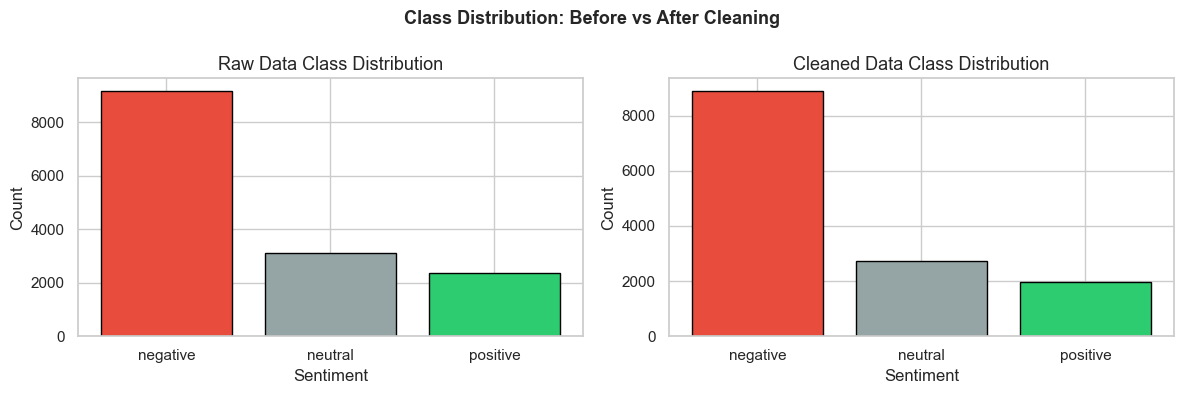

Final class distribution:
                   Count  Percentage (%)
airline_sentiment                       
negative            8907         65.4000
neutral             2744         20.1500
positive            1969         14.4600


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: Final class distribution check after cleaning
# WHY: Make sure cleaning did not accidentally remove entire classes or badly
#      distort the balance.
# ─────────────────────────────────────────────────────────────────────────────

final_dist = df_clean['airline_sentiment'].value_counts()
final_pct  = df_clean['airline_sentiment'].value_counts(normalize=True).mul(100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before
raw_dist = df_raw['airline_sentiment'].value_counts()
axes[0].bar(raw_dist.index, raw_dist.values, color=['#e74c3c','#95a5a6','#2ecc71'], edgecolor='black')
axes[0].set_title('Raw Data Class Distribution')
axes[0].set_ylabel('Count')

# After
axes[1].bar(final_dist.index, final_dist.values, color=['#e74c3c','#95a5a6','#2ecc71'], edgecolor='black')
axes[1].set_title('Cleaned Data Class Distribution')
axes[1].set_ylabel('Count')

for ax in axes:
    ax.set_xlabel('Sentiment')

plt.suptitle('Class Distribution: Before vs After Cleaning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Final class distribution:')
print(pd.DataFrame({'Count': final_dist, 'Percentage (%)': final_pct}))

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL: NOTEBOOK 1 — SUMMARY
# ─────────────────────────────────────────────────────────────────────────────

print('=' * 65)
print('           NOTEBOOK 1 — CLEANING SUMMARY')
print('=' * 65)
print(f'  Original dataset shape   : {df_raw.shape}')
print(f'  Final cleaned shape      : {df_clean.shape}')
print(f'  Total rows removed       : {df_raw.shape[0] - df_clean.shape[0]}')
print()
print('  Steps performed:')
print('    [1] Loaded raw CSV from archive/Tweets.csv')
print('    [2] Audited: missing values, duplicates, class distribution')
print('    [3] Dropped high-missingness columns (tweet_coord, *_gold)')
print('    [4] Filled categorical nulls with "unknown"; numeric with 0')
print('    [5] Removed exact-row and exact-text duplicates')
print('    [6] Applied clean_text() — lowercase, remove @mentions/URLs/')
print('        HTML/special chars')
print('    [7] Removed too-short (< 5 words) and IQR-outlier-long tweets')
print('    [8] Label-encoded target; parsed timestamps; fixed dtypes')
print()
print('  Output files:')
print('    → cleaned_data.csv')
print('=' * 65)

           NOTEBOOK 1 — CLEANING SUMMARY
  Original dataset shape   : (14640, 15)
  Final cleaned shape      : (13620, 14)
  Total rows removed       : 1020

  Steps performed:
    [1] Loaded raw CSV from archive/Tweets.csv
    [2] Audited: missing values, duplicates, class distribution
    [3] Dropped high-missingness columns (tweet_coord, *_gold)
    [4] Filled categorical nulls with "unknown"; numeric with 0
    [5] Removed exact-row and exact-text duplicates
    [6] Applied clean_text() — lowercase, remove @mentions/URLs/
        HTML/special chars
    [7] Removed too-short (< 5 words) and IQR-outlier-long tweets
    [8] Label-encoded target; parsed timestamps; fixed dtypes

  Output files:
    → cleaned_data.csv
